雷达图是以从同一点开始的轴上表示的三个或更多个定量变量的二维图表的形式显示多变量数据的图形方法。轴的相对位置和角度通常是无信息的。雷达图也称为网络图、蜘蛛图、星图、蜘蛛网图、不规则多边形、极坐标图或Kiviat图。它相当于平行坐标图，轴径向排列。
绘制雷达图需要创建极坐标子图，而非笛卡尔坐标系

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
# 设置中文
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

In [7]:
#1.数据准备
data = ['力量','速度','技术','发球','防守','经验']
scores=[100,100,100,100,100,100]

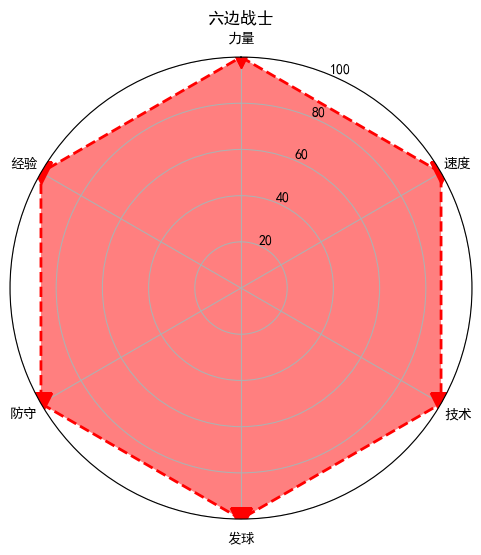

In [8]:
# 2.生成等分角度
angles = np.linspace(0,2*np.pi, len(scores), endpoint=False)

#3. 首尾闭合
scores_closed = np.concatenate(([scores,[scores[0]]]))
angles_closed = np.concatenate(([angles,[angles[0]]]))

# #4. 创建极坐标系子图
# plt.subplots() 用于创建一个画布和包含一个或多个子图的坐标系。
# figsize=(6, 6) 设置画布的宽和高均为 6 英寸，确保绘制出来的雷达图是一个正圆形。
# subplot_kw=dict(projection='polar') 是关键参数，通过字典形式将参数传给子图。
# 其中 projection='polar' 指定将子图的坐标系设置为“极坐标系”，这是绘制雷达图的基础。
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))

# #5. 绘制线条
# 使用闭合的角度和分数数据绘制雷达图的轮廓线
ax.plot(angles_closed, scores_closed, "rv--", linewidth=2, markersize=16)

# #6. 填充内部区域
# 将雷达图轮廓内部区域填充为红色
ax.fill(angles_closed, scores_closed, facecolor='r', alpha=0.5)

# #7. 设置角度标签
# 将弧度转换为角度，并在对应的雷达图轴向位置上标注文本标签
ax.set_thetagrids(angles * 180 / np.pi, data)

# #8. 设置径向范围
# 设置雷达图同心圆刻度范围为 0 到 100 
ax.set_ylim(0, 100)

# #9. 设置0°方向为上方（北面）顺时针
# 将极坐标系的 0 度起点旋转至正上方（北面）
ax.set_theta_zero_location('N')
# 设置极坐标系的方向为顺时针排列
ax.set_theta_direction(-1)

# 添加标题
plt.title("六边战士")

plt.show()

极坐标图
在平面投影中，由 X 轴和 Y 轴定位坐标；而在极坐标投影中，需要以半径和角度的形式定位坐标。极坐标投影中的半径的圆半径的大小显示，并且以每个角度为 0 度作为起点投影角度。要生成极坐标图，需要将投影类型定义为极坐标。

C:\Users\yandifei\AppData\Local\Temp\ipykernel_24520\1314675197.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(0.1, 1.1))


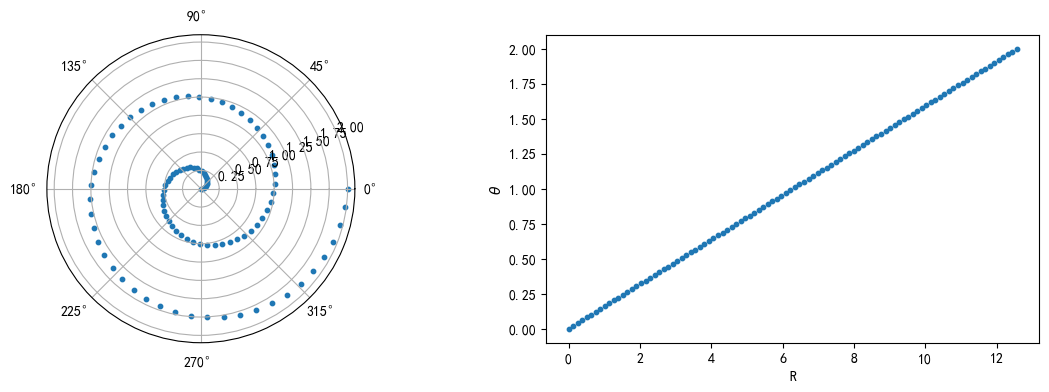

In [22]:
# 生成一个从 0 到 2 之间均匀分布、包含 100 个元素的数组，作为半径 r
r = np.linspace(0, 2, 100)
# 根据半径 r 计算对应的角度 theta（弧度值），用于生成螺旋形态
theta = 2 * np.pi * r

# 创建一个宽度英寸、高度英寸的画布
fig = plt.figure(figsize=(14, 4))

# #第一个子图
# 创建一个 1 行 2 列的子图区域，并激活第 1 个子图（左图）
# projection='polar' 参数将该子图设置为极坐标系
ax1 = plt.subplot(121, projection='polar')
# 在极坐标系中绘制散点图，传入角度 theta 和半径 r，设置标签并指定点的大小 s=10
plt.scatter(theta, r, label='极坐标系', s=10)

# 设置图例的位置
# bbox_to_anchor参数用于指定图例的锚点位置
# (0.1, 1.1)表示图例的左下角位于图表坐标系的x=0.1, y=1.1位置
# 这意味着图例会显示在图表上方稍微偏左的位置
ax.legend(bbox_to_anchor=(0.1, 1.1))

# #第二个图
# 激活 1 行 2 列中的第 2 个子图（右图），默认使用普通的直角坐标系（笛卡尔坐标系）
ax2 = plt.subplot(122)
# 在直角坐标系中同样以 theta 作为 X 轴，r 作为 Y 轴绘制散点图
ax2.scatter(theta, r, label='笛卡尔坐标系', s=10)

# 为第二个子图（ax2）设置 X 轴的文本标签为 'R'
ax2.set_xlabel('R')

# 使用 LaTeX 语法为第二个子图（ax2）设置 Y 轴的文本标签为希腊字母 θ
ax2.set_ylabel(r'$\theta$')

# 显示绘制完成的图形窗口
plt.show()

In [24]:
import jieba
from wordcloud import WordCloud

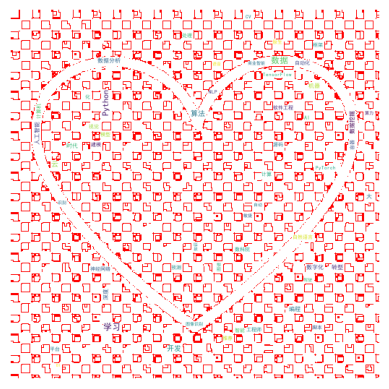

In [36]:
import jieba
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from wordcloud import WordCloud

text = (
    # 核心高频词（字号会很大）
    'Python编程 Python数据分析 人工智能 AI时代 机器学习 深度学习 大数据 数字化转型 '+ 
    # 核心技术与算法
    '数据挖掘 神经网络 计算机视觉 自然语言处理 NLP CV 算法工程师 预测模型 数据建模 '+
    # 开发与工程
    '软件工程 平台开发 源码框架 PyTorch TensorFlow 自动化脚本 容器化 云计算 云原生 '+
    # 行业与应用场景
    '数科院 智能推荐 图像识别 语音识别 自动驾驶 商业智能 BI 算力算法 知识图谱 敏捷开发'
)

# 2. 中文分词处理
words = jieba.lcut(text)
# print("分词结果：", words)
cut_words = ' '.join(words)  # 用空格将词语连接成词云所需的字符串

# 3. 导入轮廓图片（遮罩）
# 注意：图片背景最好为纯白色（#FFFFFF），这样 WordCloud 才能精准识别出轮廓
mask_image = np.array(Image.open('image.png'))

# 4. 配置词云参数
wc = WordCloud(
    font_path='simhei.ttf',     # 设置中文字体，防止中文乱码
    background_color='white',   # 设置背景颜色
    width=800,                  # 画布宽度
    height=400,                 # 画布高度
    contour_color="red",       # 轮廓颜色
    contour_width=1,               # 轮廓粗细
    mask=mask_image             # 核心：指定词云的形状轮廓
)

# 5. 正式生成与绘制
wc.generate(cut_words)          # 根据分词文本生成词云

plt.imshow(wc.to_array())       # 将词云对象转换为数组并渲染出来
plt.axis('off')                 # 关闭坐标轴刻度，让画面更美观
plt.show()                      # 显示最终的词云图

In [ ]:
# 1. 产生网格数据 (对应你截图中的 np.mgrid)
# 创建 -3 到 3 的二维网格，各 100 个点，j 代表复数步长（表示生成包含100个点的闭区间）
X, Y = np.mgrid[-3:3:100j, -3:3:100j]

# 2. 定义非线性二维动力系统方程
# 以带阻尼的非线性单摆为例：
# dx/dt = y
# dy/dt = -sin(x) - d*y (其中 d 为阻尼系数)
b = 0.25  # 阻尼系数

U = Y                  # dx/dt 对应的水平速度分量
V = -np.sin(X) - b * Y # dy/dt 对应的垂直速度分量

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(8, 6))

# 使用 streamplot 绘制系统的流线图（相轨迹）
# color 传入速度大小，用色带体现出系统变化的快慢
speed = np.sqrt(U**2 + V**2)
strm = ax.streamplot(X.T, Y.T, U.T, V.T, color=speed.T, cmap='viridis', linewidth=1.5, density=1.2)

# 4. 图表美化与细节标注
fig.colorbar(strm.lines, label='Speed (Magnitude of Vector)') # 添加速度色带

# 标注平衡点（不动点 Fixed Points）
# 原点 (0,0) 是一个稳定焦点/节点（单摆自然下垂的位置）
ax.plot(0, 0, 'ro', label='Stable Equilibrium (0,0)')
# (pi, 0) 和 (-pi, 0) 是不稳定鞍点（单摆倒立的位置）
ax.plot([np.pi, -np.pi], [0, 0], 'kx', markersize=10, label='Unstable Saddle Points')

ax.set_title('Phase Portrait of a Nonlinear 2D Dynamical System (Damped Pendulum)', fontsize=12)
ax.set_xlabel('Position (X)')
ax.set_ylabel('Velocity (Y)')
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.show()